In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("animal_disease.csv")
df.head()


,Animal,Age,Temperature,Symptom 1,Symptom 2,Symptom 3,Disease
0,cow,3,103.1,depression,painless lumps,loss of appetite,pneumonia
1,buffalo,13,104.5,painless lumps,loss of appetite,depression,lumpy virus
2,sheep,1,100.5,depression,painless lumps,loss of appetite,lumpy virus
3,cow,14,100.3,loss of appetite,swelling in limb,crackling sound,blackleg
4,sheep,2,103.6,painless lumps,loss of appetite,depression,pneumonia


In [3]:
df.tail

<bound method NDFrame.tail of         Animal  Age  Temperature                Symptom 1         Symptom 2  \
0          cow    3        103.1               depression    painless lumps   
1      buffalo   13        104.5           painless lumps  loss of appetite   
2        sheep    1        100.5               depression    painless lumps   
3          cow   14        100.3         loss of appetite  swelling in limb   
4        sheep    2        103.6           painless lumps  loss of appetite   
...        ...  ...          ...                      ...               ...   
43773     goat    9        102.2       swelling in muscle          lameness   
43774  buffalo    3        101.8         loss of appetite    sores on mouth   
43775  buffalo   15        104.1  swelling in extremities            chills   
43776      cow    9        104.9          crackling sound          lameness   
43777  buffalo    4        103.5       difficulty walking     sores on gums   

                 Symp

In [4]:
df.columns

Index(['Animal', 'Age', 'Temperature', 'Symptom 1', 'Symptom 2', 'Symptom 3',
       'Disease'],
      dtype='object')

In [5]:
df.shape

(43778, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43778 entries, 0 to 43777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Animal       43778 non-null  object 
 1   Age          43778 non-null  int64  
 2   Temperature  43778 non-null  float64
 3   Symptom 1    43778 non-null  object 
 4   Symptom 2    43778 non-null  object 
 5   Symptom 3    43778 non-null  object 
 6   Disease      43778 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.3+ MB


In [7]:
df.describe()

,Age,Temperature
count,43778.000000,43778.000000
mean,6.769131,102.269590
std,3.886739,1.400872
min,1.000000,100.000000
25%,4.000000,101.100000
50%,7.000000,102.200000
75%,10.000000,103.400000
max,15.000000,105.000000


In [8]:
df.isnull().sum()

Animal         0
Age            0
Temperature    0
Symptom 1      0
Symptom 2      0
Symptom 3      0
Disease        0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
X = df.drop("Disease", axis=1)
y = df["Disease"]


In [11]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc

results

{'Logistic Regression': 0.35290086797624487,
 'Decision Tree': 0.767702147099132,
 'Random Forest': 0.7691868433074464,
 'Gradient Boosting': 0.831772498857926}

In [16]:
pd.DataFrame(results.items(), columns=["Model","Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,Gradient Boosting,0.831772
2,Random Forest,0.769187
1,Decision Tree,0.767702
0,Logistic Regression,0.352901


In [17]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [18]:
y_pred = best_model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.831772498857926
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1969
           1       1.00      1.00      1.00      1943
           2       1.00      1.00      1.00      1940
           3       0.49      0.43      0.46      1438
           4       0.50      0.55      0.52      1466

    accuracy                           0.83      8756
   macro avg       0.80      0.80      0.80      8756
weighted avg       0.83      0.83      0.83      8756



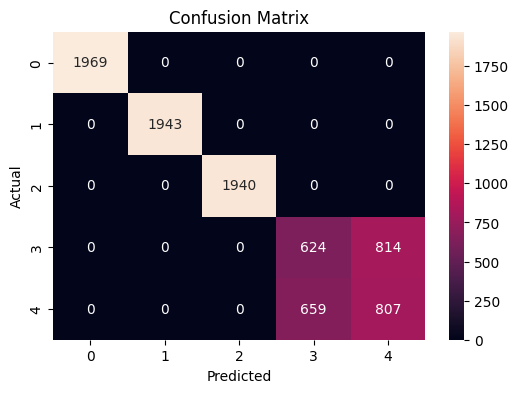

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

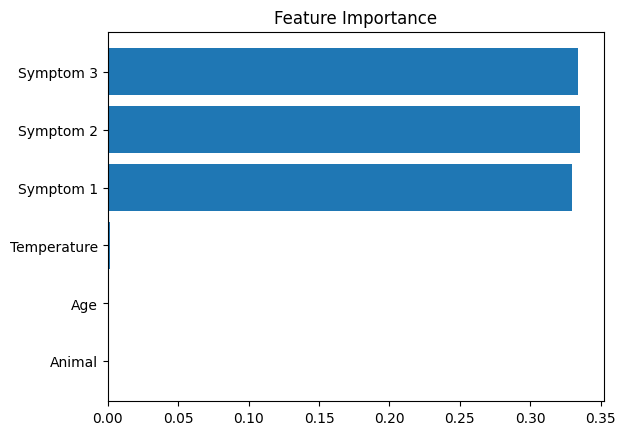

In [21]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_

    plt.barh(X.columns, importances)
    plt.title("Feature Importance")
    plt.show()

In [23]:
import joblib

joblib.dump(best_model, "best_livestock_model0.pkl")
joblib.dump(target_encoder, "label_encoder0.pkl")


['label_encoder0.pkl']